# Nara Hotéis — Análise de Dados\n
## Projeto Integrador | Análise de Dados
    
Este notebook realiza o processo completo de **análise** nas cinco bases de dados fornecidas pela Nara Hotéis.  
Cada seção segue a mesma estrutura:  
1. **Inspeção** — identificar os problemas
2. **Decisão** — discutir qual ação tomar e por quê
3. **Correção** — aplicar o tratamento com explicação linha a linha

---
## Importação das Bibliotecas
- Pandas — manupulação de dados tabulares
- Matplotlib — criação de gráficos
- Estatistica — script criado com todas as funções para análise estatísticas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import estatistica as es

---
## Carregamento das bases

`pd.read_csv()` lê um arquivo CSV e transforma em um DataFrame — a estrutura de tabela do pandas

In [3]:
hoteis = pd.read_csv('./csv/tratado/hoteis_tratado.csv')
quartos = pd.read_csv('./csv/tratado/quartos_tratado.csv')
hospedes = pd.read_csv('./csv/tratado/hospedes_tratado.csv')
avaliacoes = pd.read_csv('./csv/tratado/avaliacoes_tratado.csv')
reservas = pd.read_csv('./csv/tratado/reservas_tratado.csv')

reservas.head()

,id_reserva,id_hospede,id_quarto,id_hotel,data_checkin,data_checkout,canal_reserva,valor_diaria,status_reserva,data_reserva
0,1,203,26,3,2024-10-28,2024-10-29,Site Próprio,2344.25,Confirmada,2024-10-21
1,2,30,33,3,2024-06-03,2024-06-07,Site Próprio,469.17,Confirmada,2024-05-07
2,3,47,4,1,2024-07-18,2024-07-25,Site Próprio,2358.47,Confirmada,2024-07-10
3,4,322,23,2,2024-08-19,2024-08-20,Telefone,1743.13,Confirmada,2024-08-15
4,5,286,13,2,2023-05-17,2023-05-22,Agência de Viagem,617.85,Confirmada,2023-05-09


In [4]:
reservas['data_checkin']  = pd.to_datetime(reservas['data_checkin'],  errors='coerce')
reservas['data_checkout'] = pd.to_datetime(reservas['data_checkout'], errors='coerce')
reservas['data_reserva']  = pd.to_datetime(reservas['data_reserva'],  errors='coerce')
reservas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_reserva      1476 non-null   int64         
 1   id_hospede      1476 non-null   int64         
 2   id_quarto       1476 non-null   int64         
 3   id_hotel        1476 non-null   int64         
 4   data_checkin    1476 non-null   datetime64[us]
 5   data_checkout   1476 non-null   datetime64[us]
 6   canal_reserva   1476 non-null   str           
 7   valor_diaria    1476 non-null   float64       
 8   status_reserva  1476 non-null   str           
 9   data_reserva    1476 non-null   datetime64[us]
dtypes: datetime64[us](3), float64(1), int64(4), str(2)
memory usage: 115.4 KB


In [5]:
reservas['mes_ano_reserva'] = reservas['data_reserva'].dt.strftime('%Y-%m')
reservas['mes_ano_reserva'].value_counts()

mes_ano_reserva
2025-01    59
2025-07    59
2025-05    56
2025-06    53
2024-04    52
2025-04    51
2025-08    49
2024-03    48
2023-10    48
2023-02    48
2025-03    48
2025-09    46
2023-04    44
2024-10    42
2024-05    42
2024-06    42
2024-01    42
2024-09    41
2023-11    41
2023-06    41
2023-08    40
2023-12    40
2023-07    40
2023-05    39
2024-08    38
2023-01    38
2024-12    38
2023-09    36
2024-11    34
2023-03    34
2024-07    32
2025-02    32
2024-02    31
2022-12    31
2022-11    11
2025-10    10
Name: count, dtype: int64

---
## Medida Central

Média do valor da diária: 1.617,09  
Mediana do valor da diária: 1.563,45  
Distância entre média e mediana: __3,4%__  

A distância entre média e mediana é de aproximadamente 3,4%, portanto a média é um valor válido para media central.

In [6]:
media = es.calc_media(reservas, 'valor_diaria')
mediana = es.calc_mediana(reservas, 'valor_diaria')
distancia = es.calc_distancia(reservas, 'valor_diaria')
print(f'Média: {media}')
print(f'Mediana: {mediana}')
print(f'Distância: {distancia}')

Média: 1617.0970257452575
Mediana: 1563.455
Distância: 0.03430992625004082


---
## Valores Atípicos

IQR: 1.269,82
Limite Superior: 4.092,81  
Limite Inferior: -986,46  

### Outliers
Foram encontrados 5 outliers, com valores acima do limite superior. Reservas com os seguintes IDs: 34, 178, 321, 512 e 689

In [7]:
iqr = es.calc_iqr(reservas, 'valor_diaria')
lim_sup = es.calc_limites(reservas, 'valor_diaria')[1]
lim_inf = es.calc_limites(reservas, 'valor_diaria')[0]

print(f'IQR valor diária: {iqr}')
print(f'Limite superior: {lim_sup}')
print(f'Limite inferior: {lim_inf}')

IQR valor diária: 1269.8200000000002
Limite superior: 4092.8125
Limite inferior: -986.4675000000003


In [8]:
outliers_reservas = reservas.loc[reservas['valor_diaria'] > es.calc_limites(reservas, 'valor_diaria')[1]]
outliers_reservas = outliers_reservas.sort_values(by='valor_diaria')

In [9]:
outliers_reservas = outliers_reservas.merge(
    hoteis[['id_hotel', 'nome_hotel']],
    on='id_hotel',
    how='inner'
)

## Desempenho por Canal de Vendas

Expedia: __514.059,27__  
Booking.com: 506.550,61  
Site Próprio: 488.102,78  
Agência de Viagem: 428.237,12  
Telefone: 428.744,92  

O canal de vendas com maior ticket médio: Expedia

In [10]:
canal_maior_ticket = reservas.groupby('canal_reserva')['valor_diaria'].sum().reset_index().sort_values(by='valor_diaria')
canal_maior_ticket

,canal_reserva,valor_diaria
3,Não informado,21140.51
5,Telefone,428237.12
0,Agência de Viagem,428744.92
4,Site Próprio,488102.78
1,Booking.com,506550.61
2,Expedia,514059.27


## Overbooking

Nara Recife: __16__  
Nara Salvador: 10  
Nara Rio de Janeiro: 9  
Nara São Paulo: 7  
Nara Fortaleza: 3  

In [11]:
reservas = reservas.merge(
    hoteis[['id_hotel', 'nome_hotel']],
    on='id_hotel',
    how='left'
)
reservas.info()

<class 'pandas.DataFrame'>
RangeIndex: 1476 entries, 0 to 1475
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_reserva       1476 non-null   int64         
 1   id_hospede       1476 non-null   int64         
 2   id_quarto        1476 non-null   int64         
 3   id_hotel         1476 non-null   int64         
 4   data_checkin     1476 non-null   datetime64[us]
 5   data_checkout    1476 non-null   datetime64[us]
 6   canal_reserva    1476 non-null   str           
 7   valor_diaria     1476 non-null   float64       
 8   status_reserva   1476 non-null   str           
 9   data_reserva     1476 non-null   datetime64[us]
 10  mes_ano_reserva  1476 non-null   str           
 11  nome_hotel       1476 non-null   str           
dtypes: datetime64[us](3), float64(1), int64(4), str(4)
memory usage: 138.5 KB


In [12]:
overbooking = reservas.loc[reservas['status_reserva'] == 'Overbooking']
overbooking['mes_ano_checkin'] = pd.to_datetime(overbooking['data_checkin']).dt.strftime('%Y-%m')
overbooking = overbooking.merge(
    hoteis[['id_hotel', 'nome_hotel']],
    on='id_hotel',
    how='left'
)

In [13]:
overbooking = overbooking.merge(
    hoteis[['id_hotel', 'nome_hotel']],
    on='id_hotel',
    how='left'
)

In [14]:
count_overbooking = overbooking.groupby(['nome_hotel', 'mes_ano_checkin']).size().reset_index(name='qtd')

tabela_overbooking = count_overbooking.pivot_table(
    index='nome_hotel', 
    columns='mes_ano_checkin', 
    values='qtd', 
    fill_value=0 # Preenche com 0 os meses que não tiveram problema
)

## Volume de reservas confirmadas ao longo do tempo

In [15]:

reservas_confirmadas = reservas.loc[reservas['status_reserva'] == 'Confirmada']

tabela_linha_tempo = reservas_confirmadas.pivot_table(
    index='mes_ano_reserva', 
    columns='id_hotel', 
    values='id_reserva', 
    aggfunc='count'
).fillna(0)

## Faixa de Preço por Tipo de Quarto

Tipo de quarto Luxo foi o único que nâo apresentou outliers.

In [16]:
reservas_quartos = reservas.merge(
    quartos[['id_quarto', 'tipo_quarto']],
    on='id_quarto',
    how='inner'
)

In [17]:
tipos_quarto = reservas_quartos['tipo_quarto'].dropna().unique()

dados_para_boxplot = []
for tipo in tipos_quarto:
    valores_do_tipo = reservas_quartos.loc[reservas_quartos['tipo_quarto'] == tipo, 'valor_diaria']
    dados_para_boxplot.append(valores_do_tipo)

## Gráficos

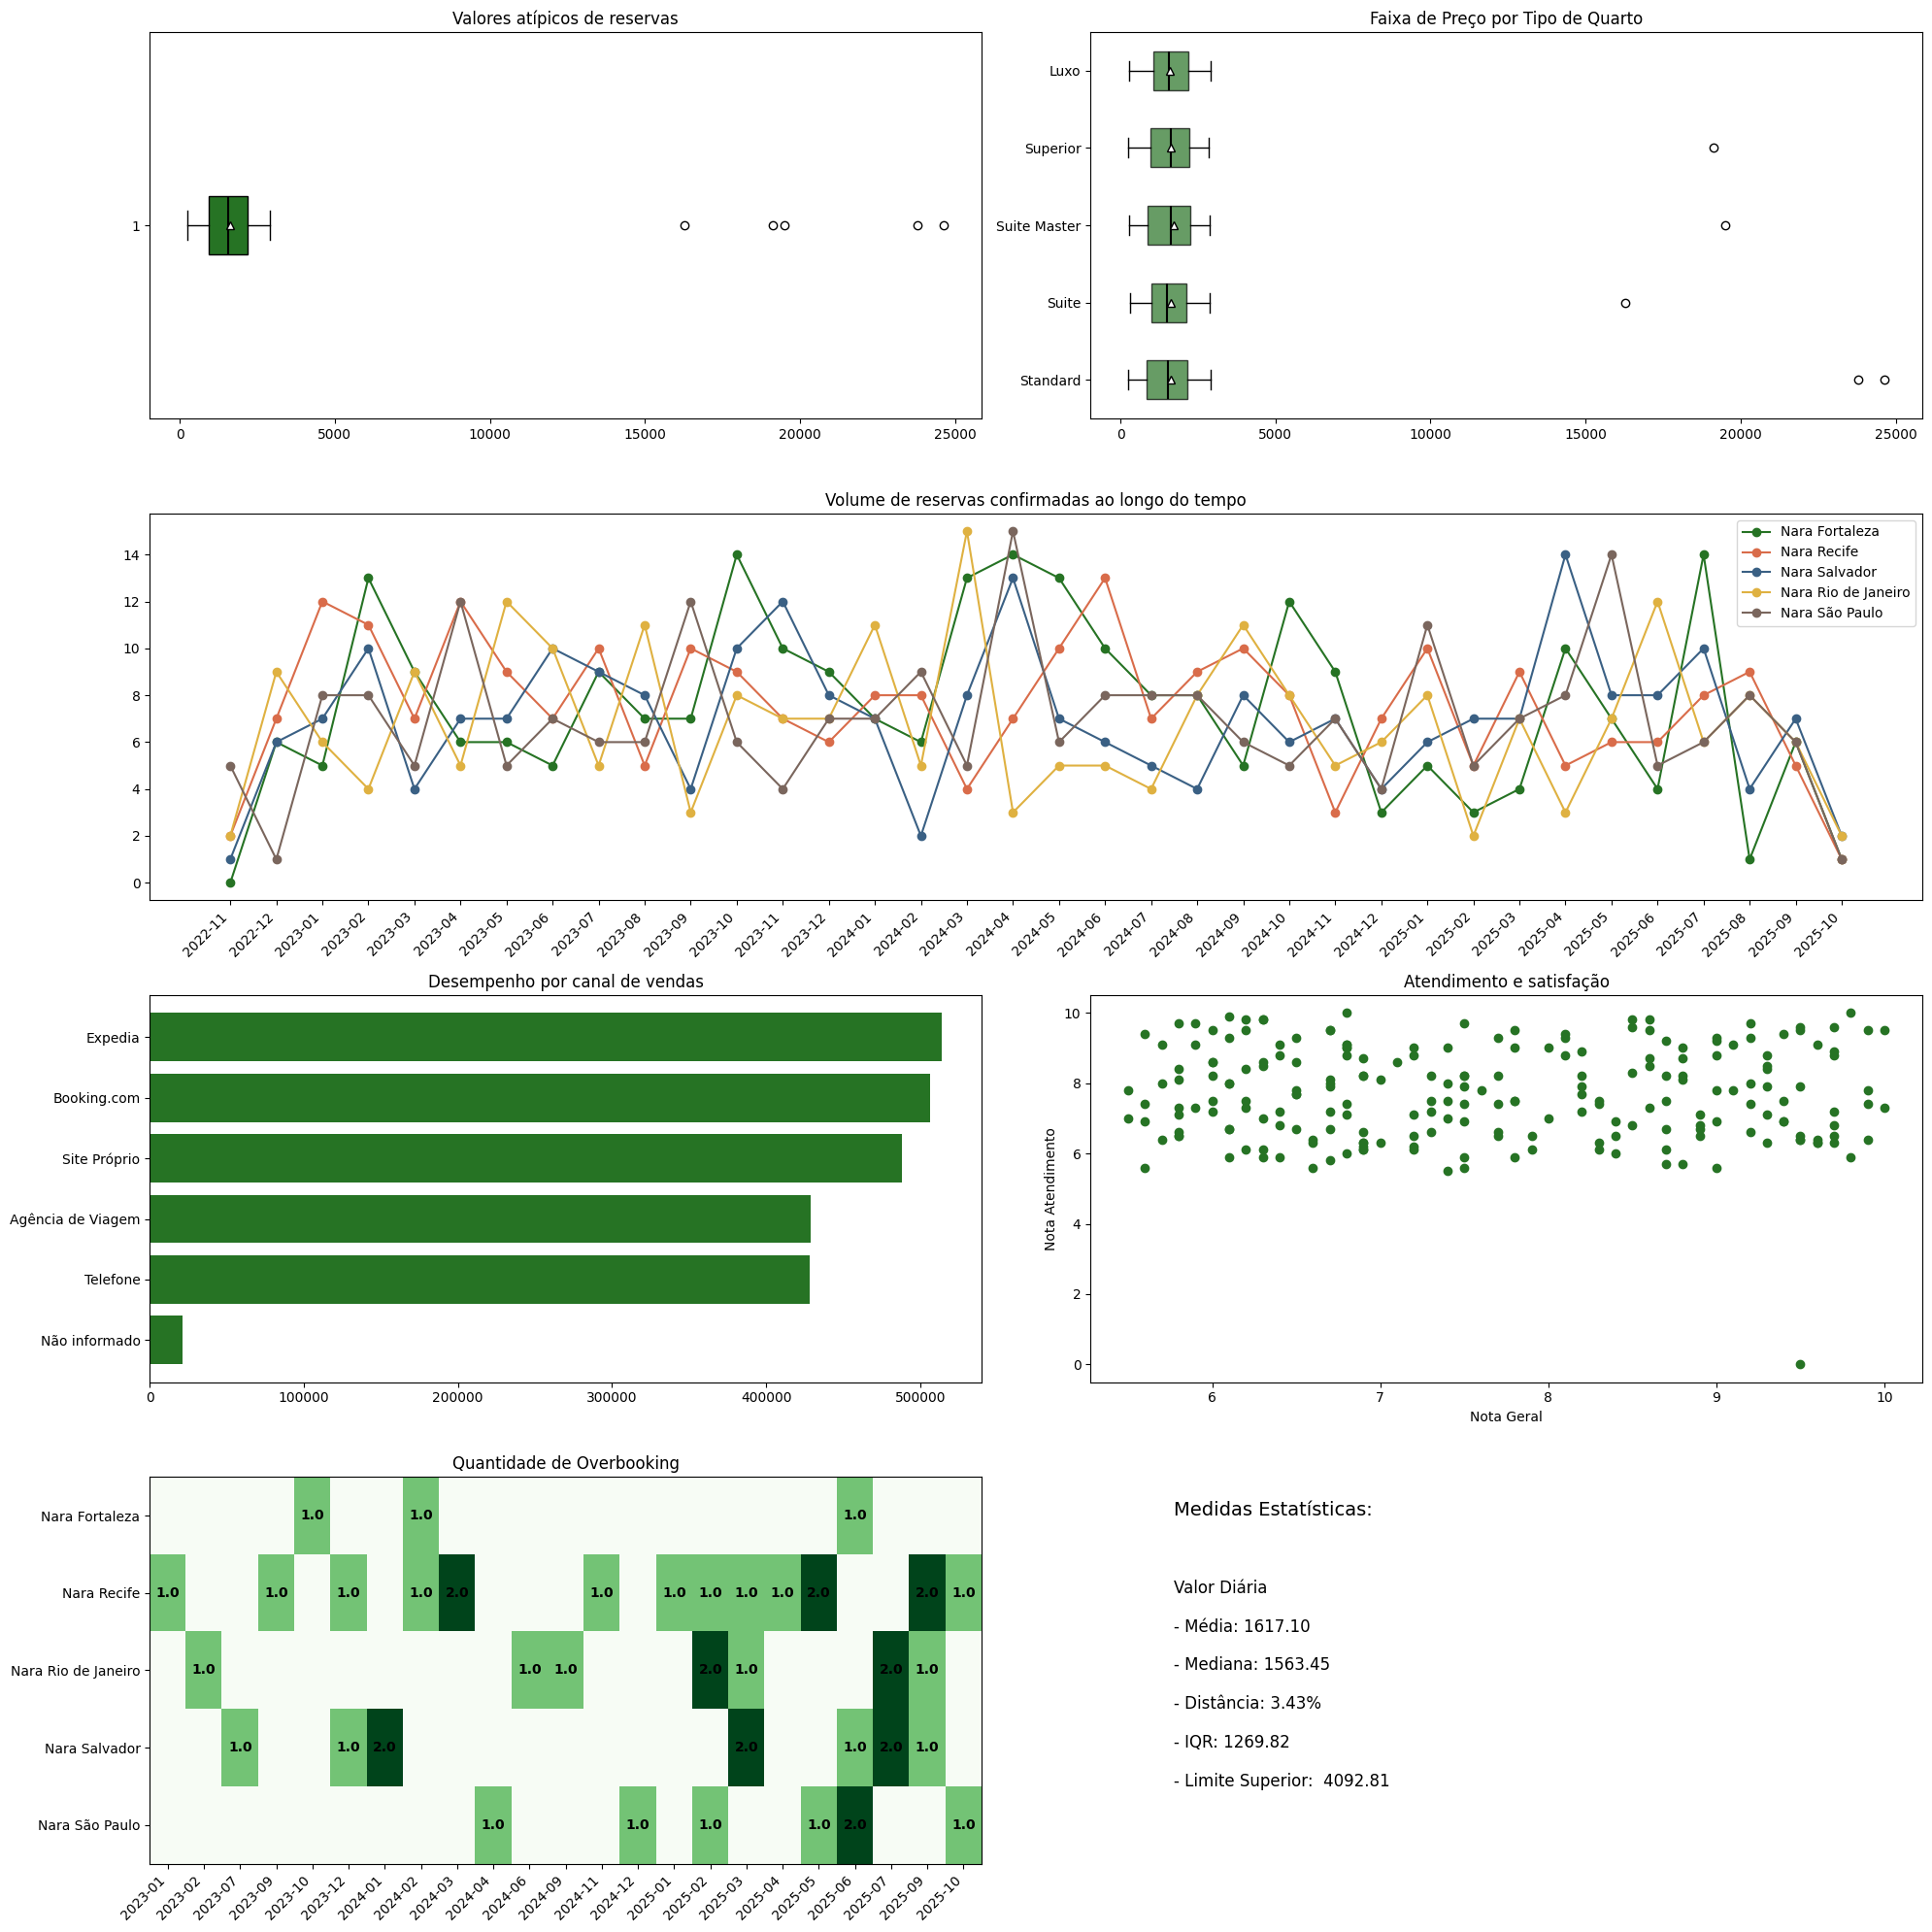

In [18]:
layout = [
    ['A', 'B'],
    ['C', 'C'],
    ['D', 'E'],
    ['F', 'G']
]

fig, axs = plt.subplot_mosaic(layout, figsize=(20, 20))

meses = tabela_linha_tempo.index


atipico_reserva = axs['A'].boxplot(es.cria_array(reservas, 'valor_diaria'), vert=False, showmeans=True, patch_artist=True)
for box in atipico_reserva['boxes']:
    box.set_facecolor('#267324')
    box.set_edgecolor('black')

for mean in atipico_reserva['means']:
    mean.set_markerfacecolor('white')
    mean.set_markeredgecolor('black')

for median in atipico_reserva['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

faixa_preco_quarto = axs['B'].boxplot(dados_para_boxplot, tick_labels=tipos_quarto, patch_artist=True, vert=False, showmeans=True)
for box in faixa_preco_quarto['boxes']:
    box.set_facecolor('#267324')
    box.set_alpha(0.7)
    box.set_edgecolor('black')

for mean in faixa_preco_quarto['means']:
    mean.set_markerfacecolor('white')
    mean.set_markeredgecolor('black')

for median in faixa_preco_quarto['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

axs['C'].plot(meses, tabela_linha_tempo[1], marker='o', color='#267324', label='Nara Fortaleza')
axs['C'].plot(meses, tabela_linha_tempo[2], marker='o', color="#d96c4a", label='Nara Recife')
axs['C'].plot(meses, tabela_linha_tempo[3], marker='o', color="#3a6084", label='Nara Salvador')
axs['C'].plot(meses, tabela_linha_tempo[4], marker='o', color="#dfb141", label='Nara Rio de Janeiro')
axs['C'].plot(meses, tabela_linha_tempo[5], marker='o', color="#7a665d", label='Nara São Paulo')

axs['D'].barh(canal_maior_ticket['canal_reserva'], canal_maior_ticket['valor_diaria'], color='#267324')

axs['E'].scatter(avaliacoes['nota_geral'], avaliacoes['nota_atendimento'], color='#267324')

for i in range(len(tabela_overbooking.index)):
    for j in range(len(tabela_overbooking.columns)):
        valor = tabela_overbooking.iloc[i, j]
        if valor > 0:
            axs['F'].text(j, i, valor, ha="center", va="center", color="black", fontweight='bold')

axs['G'].axis('off')
axs['G'].text(0.1, 0.9, 'Medidas Estatísticas:', fontsize=14, color='black')
axs['G'].text(0.1, 0.7, f'Valor Diária', fontsize=12)
axs['G'].text(0.1, 0.6, f'- Média: {media:.2f}', fontsize=12)
axs['G'].text(0.1, 0.5, f'- Mediana: {mediana:.2f}', fontsize=12)
axs['G'].text(0.1, 0.4, f'- Distância: {distancia * 100:.2f}%', fontsize=12)
axs['G'].text(0.1, 0.3, f'- IQR: {iqr:.2f}', fontsize=12)
axs['G'].text(0.1, 0.2, f'- Limite Superior:  {lim_sup:.2f}', fontsize=12)

axs['A'].set_title('Valores atípicos de reservas')
axs['B'].set_title('Faixa de Preço por Tipo de Quarto')
axs['C'].set_title('Volume de reservas confirmadas ao longo do tempo')
axs['C'].legend()
axs['D'].set_title('Desempenho por canal de vendas')
axs['E'].set_title('Atendimento e satisfação')
axs['E'].set_xlabel('Nota Geral')
axs['E'].set_ylabel('Nota Atendimento')
axs['F'].set_title('Quantidade de Overbooking')
axs['F'].set_xticks(range(len(tabela_overbooking.columns)))
axs['F'].set_xticklabels(tabela_overbooking.columns)
axs['F'].set_yticks(range(len(tabela_overbooking.index)))
axs['F'].set_yticklabels(tabela_overbooking.index)
axs['F'].imshow(tabela_overbooking, cmap='Greens', aspect='auto')

plt.setp(axs['C'].get_xticklabels(), rotation=45, ha='right')
plt.setp(axs['F'].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Nova Demanda

## Volume Mensal de Cancelamentos e No-Show por Hotel

In [33]:
reservas_noshow_cancelada = reservas.loc[(reservas['status_reserva'] == 'No-show') | (reservas['status_reserva'] == 'Cancelada')]

tabela_noshow_cancelada_tempo = reservas_noshow_cancelada.pivot_table(
    index='mes_ano_reserva', 
    columns='id_hotel', 
    values='id_reserva', 
    aggfunc='count'
).fillna(0)

## Canal de Reserva com Taxas de Cancelamento Elevadas

Os canais Telefone e Expedia possuem maior taxa de cancelamento, porém não foram encontrados outliers.

In [26]:
reservas_cancelada = reservas.loc[reservas['status_reserva'] == 'Cancelada']
reservas_cancelada['qtd_canceladas'] = reservas_cancelada['id_reserva'].count()
reservas_cancelada_canal = reservas_cancelada.groupby(['canal_reserva', 'status_reserva'])['id_reserva'].count().reset_index().sort_values(by='id_reserva', ascending=True)

media_canal = es.calc_media(reservas_cancelada, 'qtd_canceladas')
mediana_canal = es.calc_mediana(reservas_cancelada, 'qtd_canceladas')
distancia_canal = es.calc_distancia(reservas_cancelada, 'qtd_canceladas')
iqr_canal = es.calc_iqr(reservas_cancelada, 'qtd_canceladas')
lim_sup_canal = es.calc_limites(reservas_cancelada, 'qtd_canceladas')[1]

reservas_cancelada_canal

,canal_reserva,status_reserva,id_reserva
0,Agência de Viagem,Cancelada,14
3,Site Próprio,Cancelada,15
1,Booking.com,Cancelada,17
2,Expedia,Cancelada,21
4,Telefone,Cancelada,23


In [21]:
lim_sup_canal = es.calc_limites(reservas_cancelada, 'qtd_canceladas')[1]
print(lim_sup_canal)

90.0


In [22]:
outliers_cancelada_canal = reservas_cancelada_canal.loc[reservas_cancelada_canal['id_reserva'] > lim_sup_canal]
outliers_cancelada_canal

,canal_reserva,status_reserva,id_reserva


## Antecedência Média entre Reserva e Cancelamento

A média de antecedência entre a data de reserva e cancelamento é de __23 dias__

In [23]:
reservas_cancelada['antecedencia'] = reservas_cancelada['data_checkin'] - reservas_cancelada['data_reserva']
media_cancelada_ant = reservas_cancelada['antecedencia'].mean()
print(f'Média de antecedência: {media_cancelada_ant}')

Média de antecedência: 23 days 14:08:00


## Gráficos

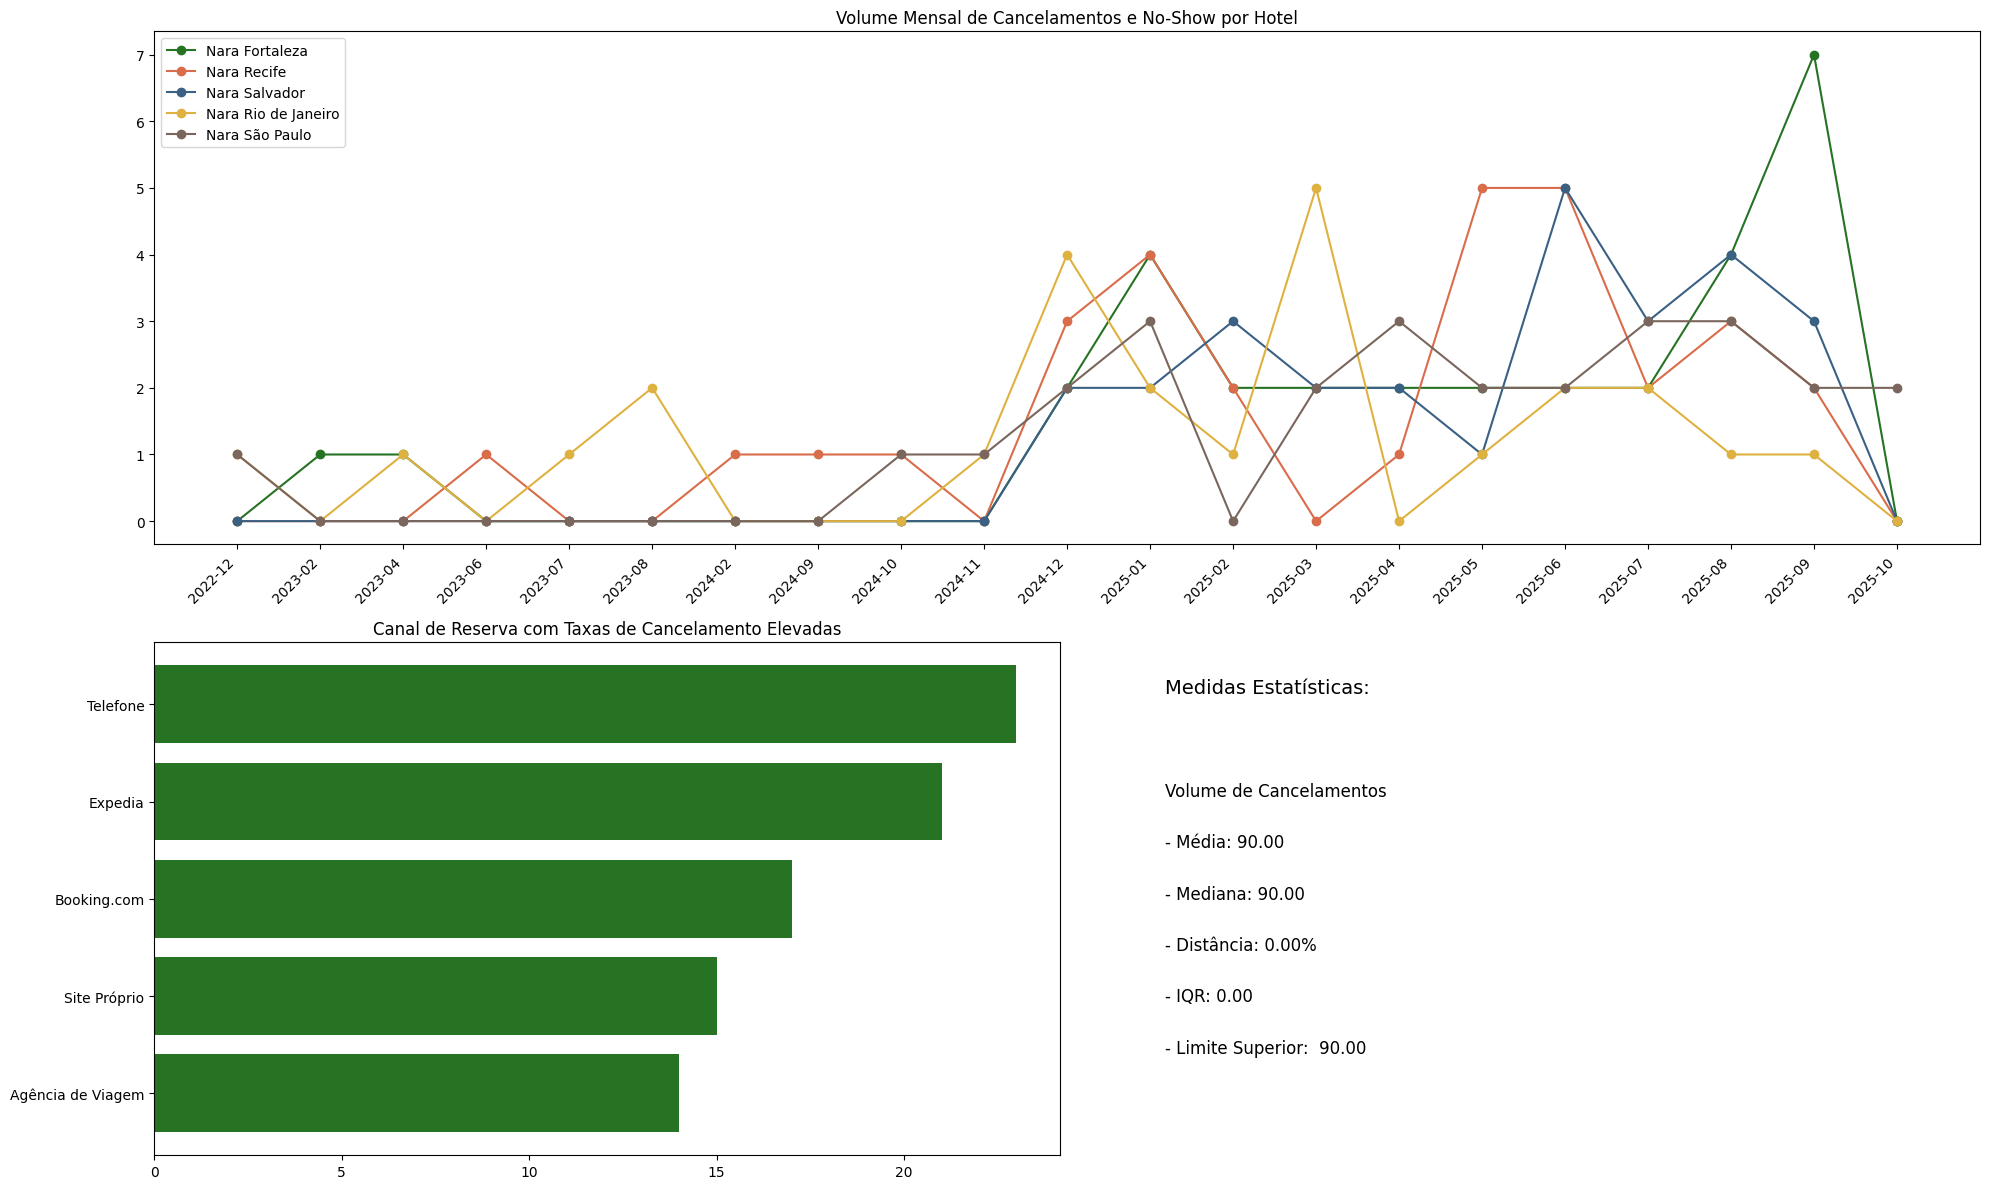

In [34]:
layout = [
    ['A', 'A'],
    ['B', 'C']
]

meses = tabela_noshow_cancelada_tempo.index

fig, axs = plt.subplot_mosaic(layout, figsize=(20, 12))

axs['A'].plot(meses, tabela_noshow_cancelada_tempo[1], marker='o', color='#267324', label='Nara Fortaleza')
axs['A'].plot(meses, tabela_noshow_cancelada_tempo[2], marker='o', color="#d96c4a", label='Nara Recife')
axs['A'].plot(meses, tabela_noshow_cancelada_tempo[3], marker='o', color="#3a6084", label='Nara Salvador')
axs['A'].plot(meses, tabela_noshow_cancelada_tempo[4], marker='o', color="#dfb141", label='Nara Rio de Janeiro')
axs['A'].plot(meses, tabela_noshow_cancelada_tempo[5], marker='o', color="#7a665d", label='Nara São Paulo')
axs['A'].legend()

axs['B'].barh(reservas_cancelada_canal['canal_reserva'], reservas_cancelada_canal['id_reserva'], color='#267324')

axs['C'].text(0.1, 0.9, 'Medidas Estatísticas:', fontsize=14, color='black')
axs['C'].axis('off')
axs['C'].text(0.1, 0.7, 'Volume de Cancelamentos', fontsize=12)
axs['C'].text(0.1, 0.6, f'- Média: {media_canal:.2f}', fontsize=12)
axs['C'].text(0.1, 0.5, f'- Mediana: {mediana_canal:.2f}', fontsize=12)
axs['C'].text(0.1, 0.4, f'- Distância: {distancia_canal * 100:.2f}%', fontsize=12)
axs['C'].text(0.1, 0.3, f'- IQR: {iqr_canal:.2f}', fontsize=12)
axs['C'].text(0.1, 0.2, f'- Limite Superior:  {lim_sup_canal:.2f}', fontsize=12)

axs['A'].set_title('Volume Mensal de Cancelamentos e No-Show por Hotel')
axs['B'].set_title('Canal de Reserva com Taxas de Cancelamento Elevadas')

plt.setp(axs['A'].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()